# Importing Modules

In [1]:
import pandas as pd
import inflection
import seaborn as sns
from matplotlib            import pyplot as plt
from sklearn.preprocessing import RobustScaler,MinMaxScaler

# Loading Dataset

In [2]:
df_raw = pd.read_csv('raw_data/train.csv')

# Data Description

In [3]:
df = df_raw.copy()
df.columns
cols_old = ['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response']
snake_case = lambda x: inflection.underscore(x)
cols_new = list(map(snake_case,cols_old))
df.columns = cols_new

In [4]:
df.sample

<bound method NDFrame.sample of             id  gender  age  driving_license  region_code  previously_insured  \
0            1    Male   44                1         28.0                   0   
1            2    Male   76                1          3.0                   0   
2            3    Male   47                1         28.0                   0   
3            4    Male   21                1         11.0                   1   
4            5  Female   29                1         41.0                   1   
...        ...     ...  ...              ...          ...                 ...   
381104  381105    Male   74                1         26.0                   1   
381105  381106    Male   30                1         37.0                   1   
381106  381107    Male   21                1         30.0                   1   
381107  381108  Female   68                1         14.0                   0   
381108  381109    Male   46                1         29.0                   0

In [5]:
df.isnull().sum()

id                      0
gender                  0
age                     0
driving_license         0
region_code             0
previously_insured      0
vehicle_age             0
vehicle_damage          0
annual_premium          0
policy_sales_channel    0
vintage                 0
response                0
dtype: int64

In [6]:
df.dtypes

id                        int64
gender                   object
age                       int64
driving_license           int64
region_code             float64
previously_insured        int64
vehicle_age              object
vehicle_damage           object
annual_premium          float64
policy_sales_channel    float64
vintage                   int64
response                  int64
dtype: object

# Data Descriptive

In [7]:
num_attributes = df.select_dtypes(include=['int64','float64'])
cat_attributes = df.select_dtypes(exclude=['int64','float64','datetime64[ns]'])

In [8]:
df['response'].value_counts(normalize=True)
# Just 12% of the customers has interested in the new product

0    0.877437
1    0.122563
Name: response, dtype: float64

In [9]:
df.describe()

,id,age,driving_license,region_code,previously_insured,annual_premium,policy_sales_channel,vintage,response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


# Feature Engineering

In [10]:
df1 = df.copy()

In [11]:
df1['vehicle_age'] = df1['vehicle_age'].apply(lambda x: 'over_2_years' if x == '> 2 Years' else 'between_1_and_2_years' if x == '1-2 Year' else 'below_1_year')

df1['vehicle_damage'] = df1['vehicle_damage'].apply(lambda x: 1 if x == 'Yes' else 0)

# EDA

In [12]:
df2 = df1.copy()

## Hypothesis List
Response >> 0: Customer is not interested // 1: Customer is interested

### Customer who is longer associated with the company is more interested in the new product - FALSE

<AxesSubplot:xlabel='response', ylabel='vintage'>

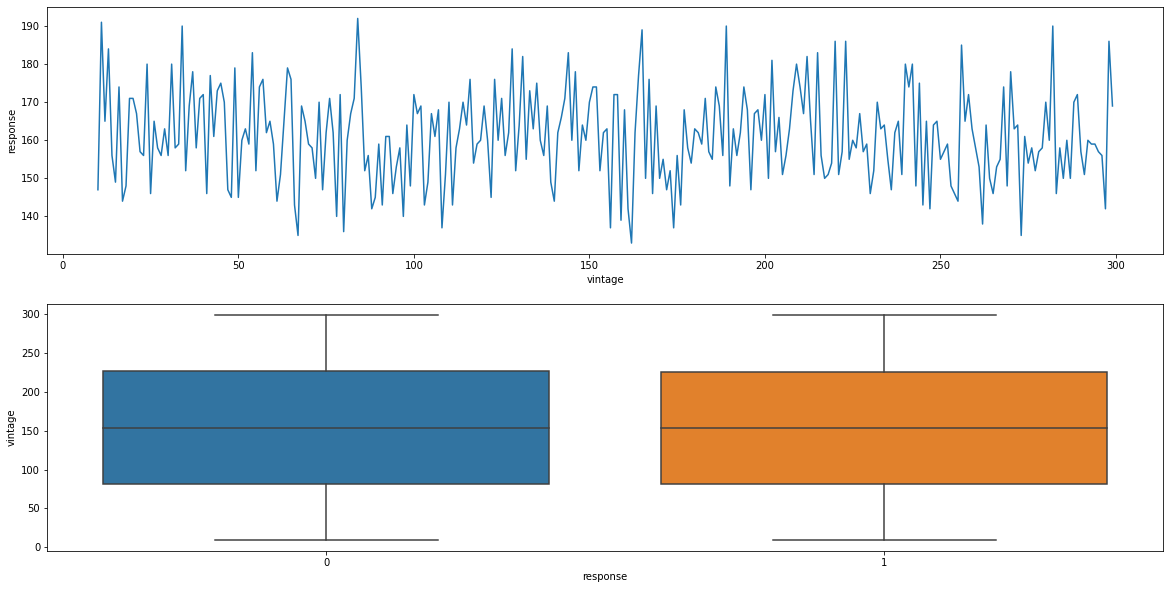

In [13]:
aux1 = df2[['vintage','response']].groupby('vintage').sum().reset_index()
plt.rcParams['figure.figsize'] = [20, 10]
plt.subplot(2,1,1)
sns.lineplot(y='response',x='vintage',data=aux1)
plt.subplot(2,1,2)
sns.boxplot(y='vintage',x='response',data=df2)

### Customer who already have vehicle insurance is more interested in the new product - FALSE

Text(0.5, 1.0, 'Interested Customers')

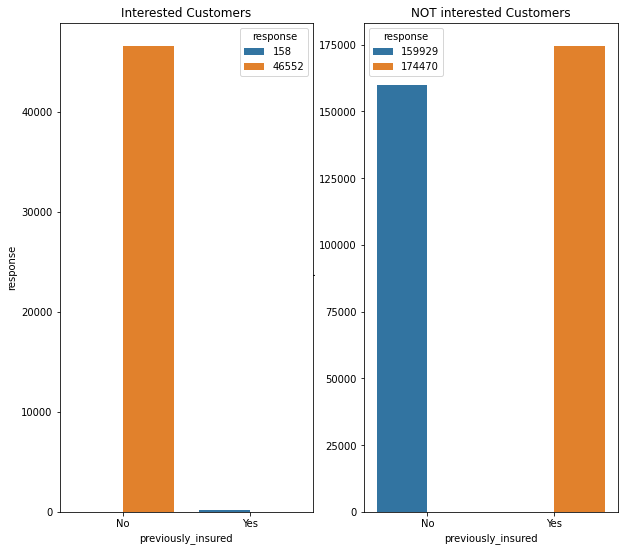

In [14]:
aux0=df2.copy()
aux0['previously_insured'] = df1['previously_insured'].apply(lambda x: 'Yes' if x == 1 else 'No')
aux1 = aux0.loc[(aux0['previously_insured'] == 'No') & (aux0['response'] == 0)].groupby('previously_insured').count().reset_index()
aux2 = aux0.loc[(aux0['previously_insured'] == 'No') & (aux0['response'] == 1)].groupby('previously_insured').count().reset_index()
aux3 = aux0.loc[(aux0['previously_insured'] == 'Yes') & (aux0['response'] == 0)].groupby('previously_insured').count().reset_index()
aux4 = aux0.loc[(aux0['previously_insured'] == 'Yes') & (aux0['response'] == 1)].groupby('previously_insured').count().reset_index()
concatenated = pd.concat([aux1.assign(dataset='aux1'), aux3.assign(dataset='aux3')])
concatenated2 = pd.concat([aux2.assign(dataset='aux2'), aux4.assign(dataset='aux4')])
plt.rcParams['figure.figsize'] = [10, 9]
plt.subplot(1,2,2)
sns.barplot(x='previously_insured',y='response',hue='response',data=concatenated).set_title('NOT interested Customers')
plt.subplot(1,2,1)
sns.barplot(x='previously_insured',y='response',hue='response',data=concatenated2).set_title('Interested Customers')

### Customer who has driving license is more interested in the new product - TRUE

Text(0.5, 1.0, 'Interested Customers')

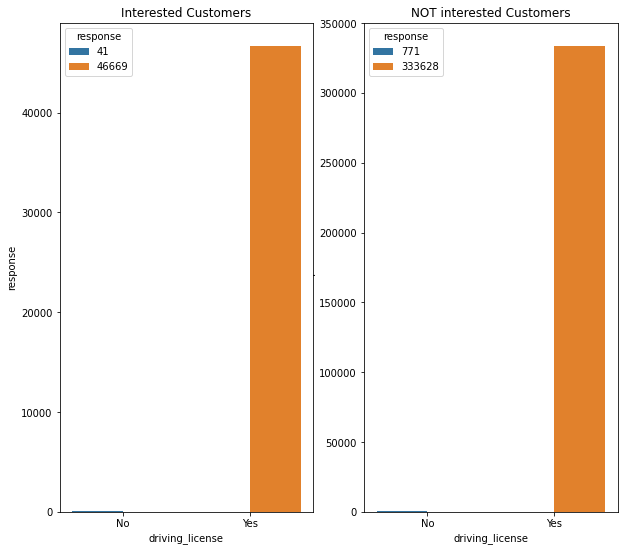

In [15]:
aux0['driving_license'] = df1['driving_license'].apply(lambda x: 'Yes' if x == 1 else 'No')
aux1 = aux0.loc[(aux0['driving_license'] == 'No') & (aux0['response'] == 0)].groupby('driving_license').count().reset_index()
aux2 = aux0.loc[(aux0['driving_license'] == 'No') & (aux0['response'] == 1)].groupby('driving_license').count().reset_index()
aux3 = aux0.loc[(aux0['driving_license'] == 'Yes') & (aux0['response'] == 0)].groupby('driving_license').count().reset_index()
aux4 = aux0.loc[(aux0['driving_license'] == 'Yes') & (aux0['response'] == 1)].groupby('driving_license').count().reset_index()
concatenated = pd.concat([aux1.assign(dataset='aux1'), aux3.assign(dataset='aux3')])
concatenated2 = pd.concat([aux2.assign(dataset='aux2'), aux4.assign(dataset='aux4')])
plt.rcParams['figure.figsize'] = [10, 9]
plt.subplot(1,2,2)
sns.barplot(x='driving_license',y='response',hue='response',data=concatenated).set_title('NOT interested Customers')
plt.subplot(1,2,1)
sns.barplot(x='driving_license',y='response',hue='response',data=concatenated2).set_title('Interested Customers')

### Elderly customer is more interested in the new product - FALSE

<AxesSubplot:xlabel='age', ylabel='response'>

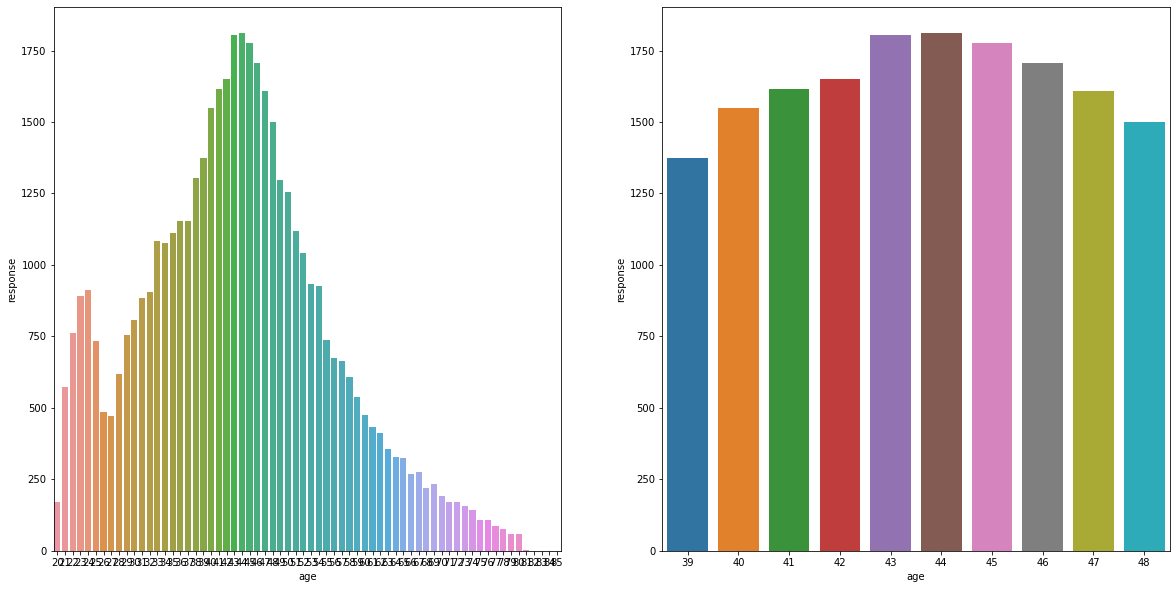

In [16]:
aux1 = df2[['age','response']].groupby('age').sum().reset_index()
plt.rcParams['figure.figsize'] = [20, 10]
plt.subplot(1,2,1)
sns.barplot(x='age',y='response',data=aux1)
plt.subplot(1,2,2)
aux2 = df2[['age','response']].groupby('age').sum().reset_index().sort_values(by='response',ascending=False).head(10)
sns.barplot(x='age',y='response',data=aux2)

### Female has more interest in the new product - FALSE

In [17]:
df['gender'].value_counts(normalize=True)

Male      0.540761
Female    0.459239
Name: gender, dtype: float64

Text(0.5, 1.0, 'Interested Customers relatively')

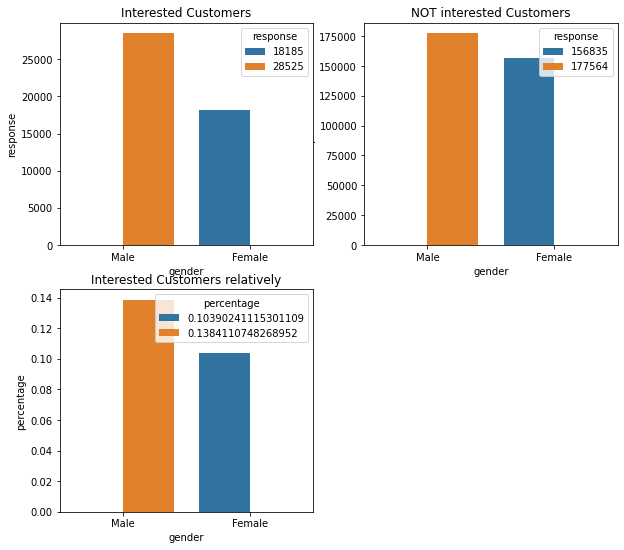

In [18]:
aux1 = df2.loc[(df2['gender'] == 'Male') & (df2['response'] == 0)].groupby('gender').count().reset_index()
aux2 = df2.loc[(df2['gender'] == 'Male') & (df2['response'] == 1)].groupby('gender').count().reset_index()
aux3 = df2.loc[(df2['gender'] == 'Female') & (df2['response'] == 0)].groupby('gender').count().reset_index()
aux4 = df2.loc[(df2['gender'] == 'Female') & (df2['response'] == 1)].groupby('gender').count().reset_index()
concatenated = pd.concat([aux1.assign(dataset='aux1'), aux3.assign(dataset='aux3')])
concatenated2 = pd.concat([aux2.assign(dataset='aux2'), aux4.assign(dataset='aux4')])
plt.rcParams['figure.figsize'] = [10, 9]
plt.subplot(2,2,2)
sns.barplot(x='gender',y='response',hue='response',data=concatenated).set_title('NOT interested Customers')
plt.subplot(2,2,1)
sns.barplot(x='gender',y='response',hue='response',data=concatenated2).set_title('Interested Customers')

# Interested Customers relatively
aux5 = aux2.iloc[0]['response'] #male
aux6 = aux4.iloc[0]['response'] #female
aux7 = df2['gender'].value_counts()
aux8 = aux5/aux7[0] #male
aux9 = aux6/aux7[1] #female
d = {'gender':['Male','Female'],'percentage':[aux8,aux9]}
d1 = pd.DataFrame(data=d)
plt.subplot(2,2,3)
sns.barplot(x='gender',y='percentage',hue='percentage',data=d1).set_title('Interested Customers relatively')

### Customer who has newer vehicles has more interest in the new product - FALSE

<AxesSubplot:xlabel='vehicle_age', ylabel='response'>

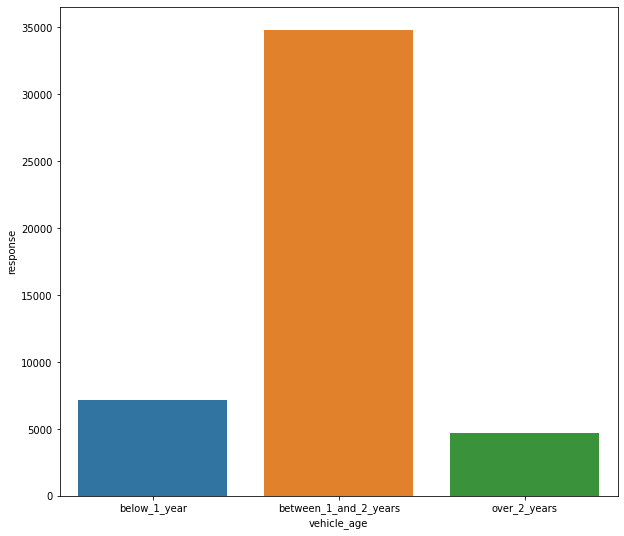

In [19]:
aux1 = df2[['vehicle_age','response']].groupby('vehicle_age').sum().reset_index()
sns.barplot(x='vehicle_age',y='response',data=aux1)

### The policy sales channel has influency if the customer will accept the new product - TRUE

<AxesSubplot:xlabel='policy_sales_channel', ylabel='response'>

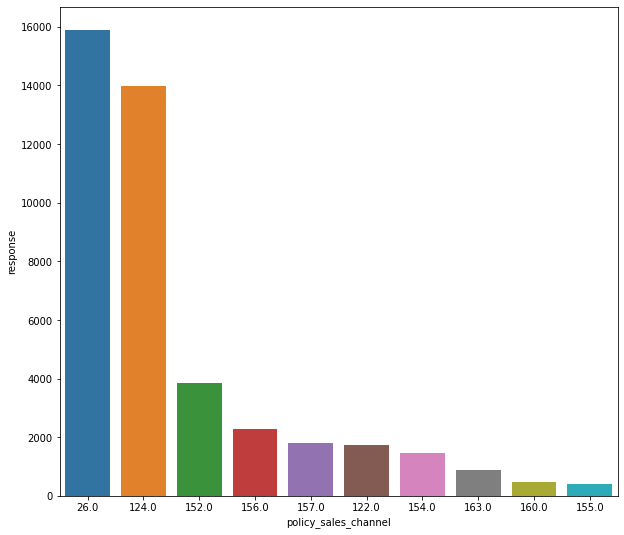

In [20]:
aux1 = df2[['policy_sales_channel','response']].groupby('policy_sales_channel').sum().reset_index()
aux1 = aux1.sort_values(by='response',ascending=False).head(10)
sns.barplot(x='policy_sales_channel',y='response',data=aux1,order=aux1['policy_sales_channel'])

### The region code that the customer is living has influency if the customer will accept the new product - TRUE

<AxesSubplot:xlabel='region_code', ylabel='response'>

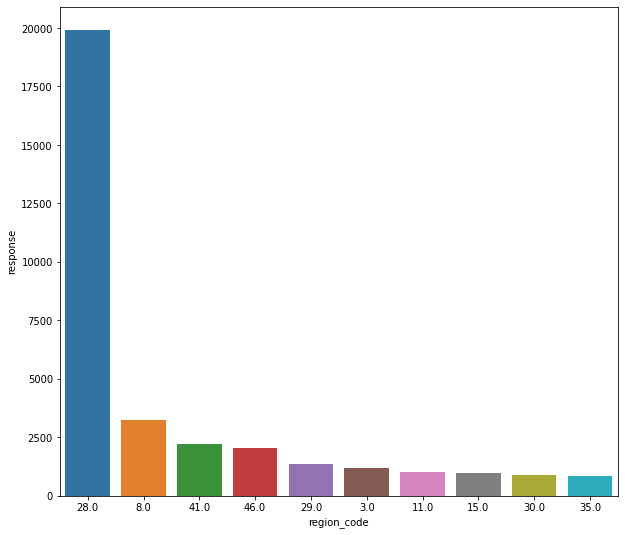

In [21]:
aux1 = df2[['region_code','response']].groupby('region_code').sum().reset_index()
aux1 = aux1.sort_values(by='response',ascending=False).head(10)
sns.barplot(x='region_code',y='response',data=aux1,order=aux1['region_code'])

### Customers with lower premium will have more interest in the new insurance - TRUE

In [22]:
df2['annual_premium'].value_counts(normalize=True)

2630.0      0.170232
69856.0     0.000367
39008.0     0.000108
38287.0     0.000100
45179.0     0.000100
              ...   
14838.0     0.000003
52535.0     0.000003
15182.0     0.000003
143525.0    0.000003
69845.0     0.000003
Name: annual_premium, Length: 48838, dtype: float64

<AxesSubplot:xlabel='annual_premium', ylabel='response'>

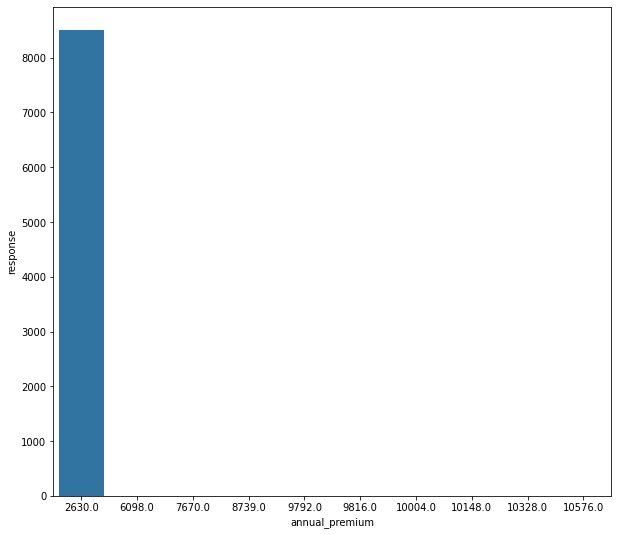

In [23]:
aux1 = df2[['annual_premium','response']].groupby('annual_premium').sum().reset_index()
aux1 = aux1.sort_values(by='annual_premium',ascending=True).head(10)
sns.barplot(x='annual_premium',y='response',data=aux1)

### Customer who got his/her vehicle damaged in the past will accept the new product - TRUE

<AxesSubplot:xlabel='vehicle_damage', ylabel='response'>

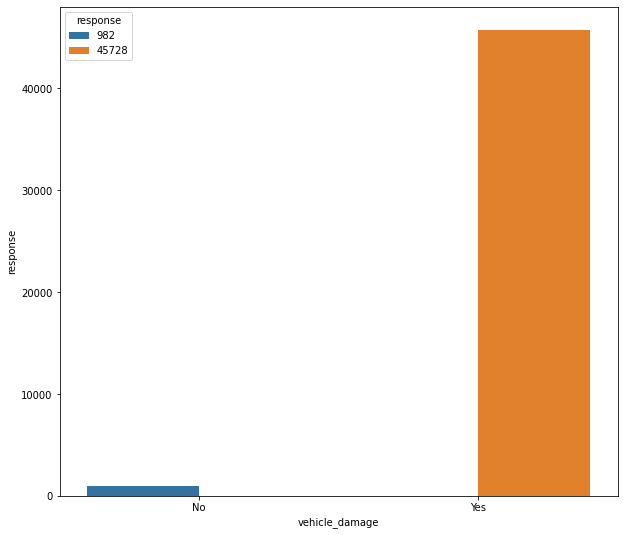

In [24]:
aux0['vehicle_damage'] = df1['vehicle_damage'].apply(lambda x: 'Yes' if x == 1 else 'No')
aux1 = aux0[['vehicle_damage','response']].groupby('vehicle_damage').sum().reset_index()
sns.barplot(x='vehicle_damage',y='response',hue='response',data=aux1)

# Data Preparation

In [28]:
df3 = df2.copy()

In [29]:
## Rescaling
rs = RobustScaler()
mms = MinMaxScaler()
# age - MixMaxScaler
df3['age'] = mms.fit_transform(df3[['age']].values)
# vintage - MinMaxScaler
df3['vintage'] = mms.fit_transform(df3[['vintage']].values)
# annual_premium - RobustScaler
df3['annual_premium'] = rs.fit_transform(df3[['annual_premium']].values)


## Enconding
# region_code - Frequency encoder / Target enconder
target_encode_region_code = df3.groupby( 'region_code' )['response'].mean()
df3.loc[:, 'region_code'] = df3['region_code'].map(target_encode_region_code)

# gender - One hot encoder
df3 = pd.get_dummies(df3,prefix=['gender'],columns=['gender'])

# vehicle age - Ordinal encoder
vehage_dict = {'below_1_year':1,'between_1_and_2_years':2,'over_2_years':3}
df3['vehicle_age'] = df3['vehicle_age'].map(vehage_dict)

# policy_sales_channel - Frequency encoder / Target enconder
fe_policy_sales_channel = df3.groupby( 'policy_sales_channel' ).size()/len(df3) 
df3.loc[:, 'policy_sales_channel'] = df3['policy_sales_channel'].map(fe_policy_sales_channel)
